## Problem Statement
> Develop a binary classification model that predicts whether an observation belongs to the diabetic or non-diabetic class based on the available clinical features.

## Dataset
The dataset used is the Pima Indian Diabetes Database from Kaggle. The link is https://www.kaggle.com/datasets/mragpavank/diabetes

## Evaluation
> Primary evaluation metric: Recall. The goal is to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive. A target recall of 90% will be investigated, while also monitoring precision and other relevant metrics.

## Features
1. Pregnancies: Number of times pregnant.
2. Glucose: Plasma glucose concentration from a oral glucose tolerance test.
3. Blood Pressure: Diastolic blood pressure (mm Hg).
4. Skin Thickness: Triceps skin fold thickness (mm).
5. Insulin: 2-Hour serum insulin (μU/ml).
6. BMI: Body mass index (weight in kg/(height in m)²).
7. Diabetes Pedigree Function: Score providing information on diabetes history in relatives.
8. Age: Age in years.
9. Outcome (0 for non-diabetic, 1 for diabetic)

## Some Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.

### This is a remodel of the modelling notebook

## Models used for baseline
1. DummyClassifier: Serves as a sanity check for other models
2. LogisticRegression: Serves as a baseline to explore linear relationships
3. KNN: Useful for small datasets
4. SVC: To explore the non-linear boundaries
5. DecisionTreeClassifier: Tree-based Baseline for handling non-linear relationships
6. RandomForestClassifier: It is a more powerful tree-based model, less prone to overfitting

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/diabetes.csv')

## Creating a Baseline Model

In [3]:
X = df.drop('Outcome', axis=1)
y = df.Outcome

In [4]:
# Stratification is used because the target variable is imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
# Columns with encoded 0 missing values
zero_categories = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Remaining Columns
others_column = [col for col in X_train.columns if col not in zero_categories]

In [6]:
# Preprocessing steps
# Impute strategy - Median
# Scaler - StandardScaler

zero = Pipeline(steps=[
    ('impute', SimpleImputer(missing_values=0, strategy='median')),
    ('scaler', StandardScaler())
])
others = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('zero', zero, zero_categories),
    ('others', others, others_column)
], remainder='passthrough')

preprocessing_without_scale = ColumnTransformer(transformers=[
    ('impute', SimpleImputer(missing_values=0, strategy='median'), zero_categories)
], remainder='passthrough')

In [7]:
models = {
    'dummy classifier': DummyClassifier(strategy='stratified', random_state=42),
    'logistic regression': Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))]),
    'KNN': Pipeline(steps=[('preprocesing', preprocessing), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'SVC': Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC(probability=True, random_state=42))]),
    'Decision Tree': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])
}

In [8]:
# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
     "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision"
}

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
results = {}

for model, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        verbose=2
    )

    results[model] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        # "Accuracy Std": scores["test_accuracy"].std(),
        
        "Precision Mean": scores["test_precision"].mean(),
        # "Precision Std": scores["test_precision"].std(),
        
        "Recall Mean": scores["test_recall"].mean(),
        # "Recall Std": scores["test_recall"].std(),
        
        "F1 Mean": scores["test_f1"].mean(),
        # "F1 Std": scores["test_f1"].std(),
        
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        # "ROC-AUC Std": scores["test_roc_auc"].std(),
        
        "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        # "Balanced_Accuracy Std": scores["test_balanced_accuracy"].std(),
        
        "Average_precision Mean": scores["test_average_precision"].mean(),
        # "Average_precision Std": scores["test_average_precision"].std()
    }

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.1s


...

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.8s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.3s finished


In [11]:
results_df = pd.DataFrame(results).T

In [12]:
results_df

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced_Accuracy Mean,Average_precision Mean
dummy classifier,0.578155,0.390244,0.373754,0.381813,0.530627,0.530627,0.364968
logistic regression,0.788231,0.763808,0.574751,0.654545,0.843364,0.738625,0.747125
KNN,0.729588,0.636708,0.565449,0.593861,0.784332,0.691474,0.616013
SVC,0.780128,0.741534,0.584164,0.648462,0.833308,0.734582,0.726241
Decision Tree,0.679168,0.539606,0.546733,0.542422,0.648367,0.648367,0.453403
Random Forest,0.760589,0.693317,0.579734,0.627312,0.816324,0.718617,0.703715


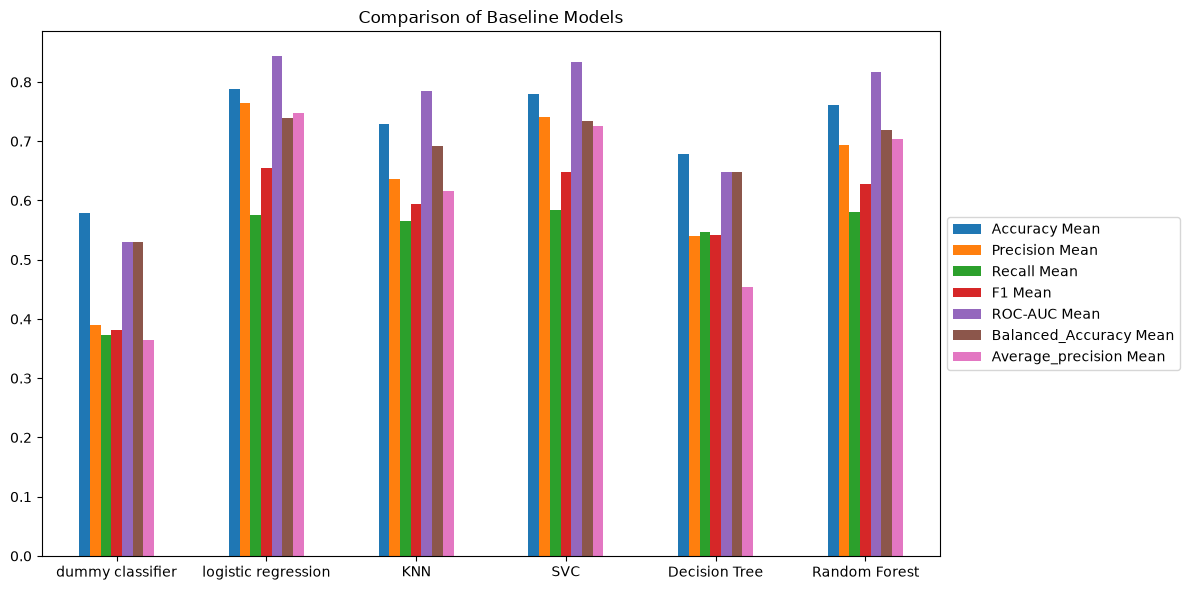

In [13]:
ax = results_df.plot.bar(
    title='Comparison of Baseline Models',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

Using the current baseline configurations, SVC, Logistic Regression and Random Forest performed strongest according to Average Precision.

## Hyperparameter Tuning

### Logistic Regression

In [14]:
lr_model = Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))])

In [15]:
grid = [
    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [0],
    "model__solver": ['lbfgs', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']},

    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [1],
    "model__solver": ['saga', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']}
]

In [16]:
def RandSearch(model, grid):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=50,
        cv=cv,
        verbose=2,
        scoring='average_precision'
    )
    
    search.fit(X_train, y_train)

    return search

def GridSearch(model, grid):
    search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=cv,
        verbose=2,
        scoring='average_precision'
    )
    
    search.fit(X_train, y_train)

    return search

In [17]:
lr_search = RandSearch(lr_model, grid)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__C=0.1, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=10, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END model__C=100, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=0, model__max_iter=310, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__l1_ratio=0, model__max_iter=110, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None,

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END model__C=0.1, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=0.1, model__class_weight=None, model__l1_ratio=1, model__max_iter=10, model__solver=saga; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=100, model__class_weight=None, model__l1_ratio=0, model__max_iter=410, model__solver=

In [18]:
lr_search.best_score_

np.float64(0.7516949416749877)

In [19]:
lr_search.best_params_

{'model__solver': 'liblinear',
 'model__max_iter': 10,
 'model__l1_ratio': 1,
 'model__class_weight': 'balanced',
 'model__C': 0.1}

In [20]:
grid_lr = [
    {"model__C": [0.01, 0.1, 1],
     "model__l1_ratio" : [1],
    "model__solver": ['liblinear'],
     "model__max_iter": [350, 400, 450],
    "model__class_weight": ['balanced']},
]

lr_grsearch = GridSearch(lr_model, grid_lr)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=350, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=400, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__l1_ratio=1, model__max_iter=400, model__solver=libl

In [21]:
lr_grsearch.best_score_

np.float64(0.7516949416749877)

In [22]:
lr_grsearch.best_params_

{'model__C': 0.1,
 'model__class_weight': 'balanced',
 'model__l1_ratio': 1,
 'model__max_iter': 350,
 'model__solver': 'liblinear'}

In [23]:
def cv_evaluate(model):
    results = {}
    scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            verbose=2
        )
    
    results = {
            "Accuracy Mean": scores["test_accuracy"].mean(),        
            "Precision Mean": scores["test_precision"].mean(),
            "Recall Mean": scores["test_recall"].mean(),        
            "F1 Mean": scores["test_f1"].mean(),        
            "ROC-AUC Mean": scores["test_roc_auc"].mean(),        
            "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),        
            "Average_precision Mean": scores["test_average_precision"].mean()
        }

    return results

In [24]:
lr_eval = cv_evaluate(lr_grsearch.best_estimator_)

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


In [25]:
comparison = pd.DataFrame([lr_eval], index=['LogisticRegression'])

### SVC 

In [26]:
svc_model = Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC(probability=True, random_state=42))])

In [27]:
grid_dist = [
    {'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__kernel': ['linear'],
    'model__class_weight': [None, 'balanced']},

    {
     'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__kernel': ['rbf'],
        'model__class_weight': [None, 'balanced'],
        'model__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

In [28]:
svc_search = RandSearch(svc_model, grid_dist)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf; total time=   0.0s
[CV] END model__C=1, model__class_weight=balanced, model__kernel=linear; total time=   0.0s


...

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=10, model__class_weight=None, model__gamma=1, model__kernel=rbf; total time=   0.1s
[CV] END model__C=10, model__class_weight=None, model__gamma=1, model__kernel=rbf; total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=10, model__class_weight=None, model__gamma=1, model__kernel=rbf; total time=   0.1s
[CV] END model__C=10, model__class_weight=None, model__gamma=1, model__kernel=rbf; total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [29]:
svc_search.best_score_

np.float64(0.7533582059784381)

In [30]:
svc_search.best_params_

{'model__kernel': 'linear', 'model__class_weight': None, 'model__C': 1}

In [31]:
grid_param = {
    'model__kernel': ['linear'],
    'model__class_weight': ['balanced', None],
    'model__C': [0.01, 0.1, 1, 10, 100]
}

In [32]:
svc_grsearch = GridSearch(svc_model, grid_param)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=0.01, model__class_weight=balanced, model__kernel=linear; total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=0.01, model__class_weight=balanced, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__kernel=linear; total time=   0.0s


...

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=100, model__class_weight=None, model__kernel=linear; total time=   1.3s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END model__C=100, model__class_weight=None, model__kernel=linear; total time=   1.9s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [33]:
svc_grsearch.best_params_

{'model__C': 10, 'model__class_weight': None, 'model__kernel': 'linear'}

In [34]:
svc_eval = cv_evaluate(svc_grsearch.best_estimator_)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.2s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.2s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.2s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.4s finished


In [35]:
comparison = pd.concat([comparison, pd.DataFrame([svc_eval], index=['SVC'])])

### RandomForestClassifier

In [36]:
rf_model = Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])

In [37]:
grid_dist = {
    'model__n_estimators': np.random.randint(10, 1000, size=5),
    'model__max_depth': [None, 5, 10, 20, 30, 50],
    'model__min_samples_split': [2, 5, 10, 20, 50],
    'model__min_samples_leaf': [1, 2, 4, 8, 10],
    'model__max_features': ['sqrt', 'log2', 0.2, 0.4, None],
    'model__class_weight': [None, 'balanced']
}


In [38]:
rf_search = RandSearch(rf_model, grid_dist)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__class_weight=None, model__max_depth=50, model__max_features=0.2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=729; total time=   2.3s
[CV] END model__class_weight=None, model__max_depth=50, model__max_features=0.2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=729; total time=   2.5s
[CV] END model__class_weight=None, model__max_depth=50, model__max_features=0.2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=729; total time=   2.5s
[CV] END model__class_weight=None, model__max_depth=50, model__max_features=0.2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=729; total time=   2.5s
[CV] END model__class_weight=None, model__max_depth=50, model__max_features=0.2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=729; total time=   2.5s
[CV] END model__class_weight=None, mod

In [39]:
rf_search.best_score_

np.float64(0.7440440828433037)

In [40]:
rf_search.best_params_

{'model__n_estimators': np.int32(729),
 'model__min_samples_split': 50,
 'model__min_samples_leaf': 2,
 'model__max_features': 0.4,
 'model__max_depth': 20,
 'model__class_weight': None}

In [44]:
grid = {'model__n_estimators': [700, 800],
 'model__min_samples_split': [50],
 'model__min_samples_leaf': [4],
 'model__max_features': [0.4],
 'model__max_depth': [None, 5],
 'model__class_weight': [None, 'balanced']}

In [45]:
rf_grsearch = GridSearch(rf_model, grid)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__class_weight=None, model__max_depth=None, model__max_features=0.4, model__min_samples_leaf=4, model__min_samples_split=50, model__n_estimators=700; total time=   2.6s
[CV] END model__class_weight=None, model__max_depth=None, model__max_features=0.4, model__min_samples_leaf=4, model__min_samples_split=50, model__n_estimators=700; total time=   2.6s
[CV] END model__class_weight=None, model__max_depth=None, model__max_features=0.4, model__min_samples_leaf=4, model__min_samples_split=50, model__n_estimators=700; total time=   2.5s
[CV] END model__class_weight=None, model__max_depth=None, model__max_features=0.4, model__min_samples_leaf=4, model__min_samples_split=50, model__n_estimators=700; total time=   2.6s
[CV] END model__class_weight=None, model__max_depth=None, model__max_features=0.4, model__min_samples_leaf=4, model__min_samples_split=50, model__n_estimators=700; total time=   2.6s
[CV] END model__class_wei

In [46]:
rf_grsearch.best_params_

{'model__class_weight': None,
 'model__max_depth': None,
 'model__max_features': 0.4,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 50,
 'model__n_estimators': 800}

In [47]:
rf_eval = cv_evaluate(rf_grsearch.best_estimator_)

[CV] END .................................................... total time=   2.9s
[CV] END .................................................... total time=   3.1s
[CV] END .................................................... total time=   3.1s
[CV] END .................................................... total time=   3.1s
[CV] END .................................................... total time=   3.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   15.6s finished


In [48]:
comparison = pd.concat([comparison, pd.DataFrame([rf_eval], index=['RandomForestClassifier'])])

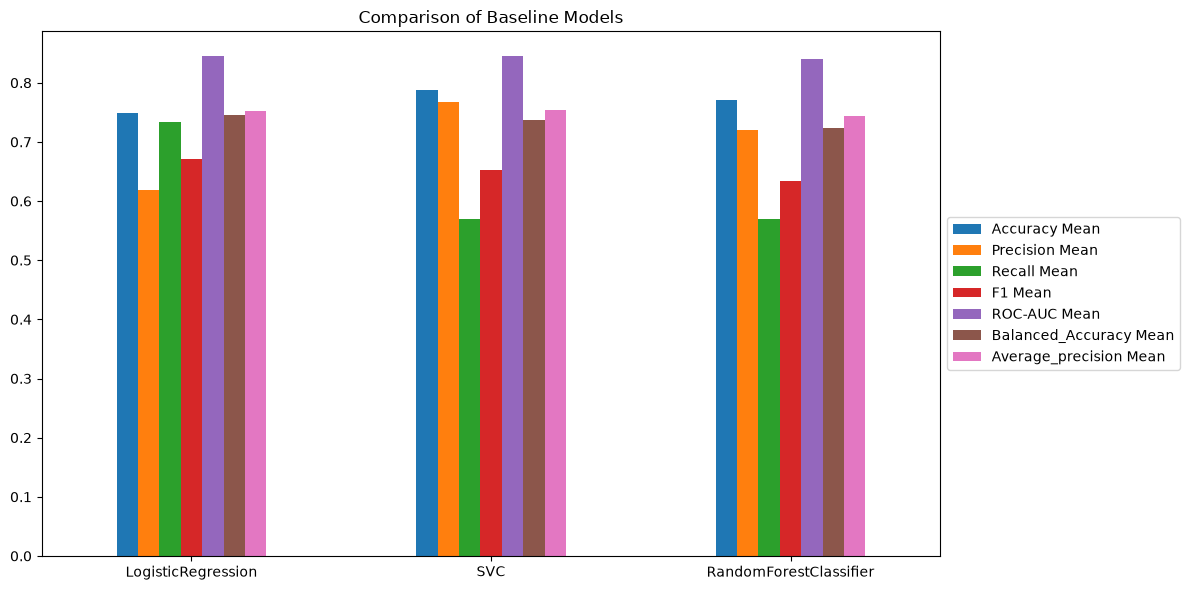

In [49]:
ax = comparison.plot.bar(
    title='Comparison of Baseline Models',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

### Threshold Tuning

### Logistic Regression

In [57]:
def threshold_tuning(model, X_train, y_train):
    oof_probs_positive = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:,1]
    results = {}
    threshold = [0.2, 0.3, 0.4]
    for t in threshold:
        preds = (oof_probs_positive >= t).astype(int)
        recall = recall_score(y_train, preds)
        results[t] = recall

    return results

In [60]:
tuned_lr = threshold_tuning(lr_grsearch.best_estimator_, X_train, y_train)

In [61]:
tuned_lr

{0.2: 0.9953271028037384, 0.3: 0.9485981308411215, 0.4: 0.8551401869158879}

### SVC

In [62]:
tuned_svc = threshold_tuning(svc_grsearch.best_estimator_, X_train, y_train)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The

In [63]:
tuned_svc

{0.2: 0.9018691588785047, 0.3: 0.7710280373831776, 0.4: 0.6635514018691588}

### RandomForest

In [65]:
tuned_rf = threshold_tuning(rf_grsearch.best_estimator_, X_train, y_train)

In [66]:
tuned_rf

{0.2: 0.9299065420560748, 0.3: 0.8317757009345794, 0.4: 0.6962616822429907}

Using threshold values of 0.2, 0.3 and 0.4, Logistic Regression had the highest recall score with 0.995 at 0.2 threshold. This meets the goal to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive and to investigate a target recall of 90%.